# Analisis Data Eksploratori

## Memahami Struktur Data

In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [55]:
from sklearn.datasets import load_diabetes

In [56]:
df=pd.read_excel('https://docs.google.com/spreadsheets/d/1rRw1XlITsRME-AHXggmS14BjrMvMqHqBHtmDS7XQY3M/export?format=xlsx',sheet_name='Paid-Transaction',skiprows=[0],usecols=[x for x in range(1,12)])
df

,Paid Date,Order Number,First Name,Last Name,Meta Category,Product Name,Transaction Amount,Seller Discount,Sales Discount,Delivery Fee,Other Discount
0,20170724,201707240088517,elvride,aries,Babies/ Kids,Pineapple Hat Anak Ala Korea - 6M - 4Y - Unise...,300000,153000,10200.0,9000,0.0
1,20170701,201707018889790,BASIR,Ninuk,Service/ Mokado,Pulsa BOLT 150.000,287800,68000,0.0,0,0.0
2,20170707,201707079264675,Citra,Ardi,Service/ Mokado,"XTRA Combo 12X 6GB, 12bln",35000,0,700.0,0,0.0
3,20170720,201707209945714,Dian,Renaldi,Fashion,Square Foldable Travel Bag / Tas Koper Luggage...,85000,0,5900.0,0,0.0
4,20170722,201707220002354,rizal,Tamba,Gadget/ Komputer,Samsung Galaxy Note 5 Gold,81000,0,5600.0,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
11995,20171201,201712012704898,Fitrah,gina,Service/ Mokado,"Xtra Combo 12GB, 30hr",333000,300000,2300.0,0,0.0
11996,20171203,201712032723513,Djebeng,Shinta,Service/ Mokado,"Xtra Combo 12GB, 30hr",280000,222500,0.0,0,0.0
11997,20171204,201712042740205,Amik,Elan,Home/ Food,Kreta - Kripik Tempe Indonesia - Rasa Jomblo d...,150000,81000,4800.0,0,0.0
11998,20171207,201712072778621,Anna,asih,Gadget/ Komputer,Samsung Galaxy J5 Pro Garansi Resmi Special Price,475000,400000,0.0,0,0.0


In [57]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Paid Date           12000 non-null  int64  
 1   Order Number        12000 non-null  int64  
 2   First Name          11996 non-null  object 
 3   Last Name           11996 non-null  object 
 4   Meta Category       12000 non-null  object 
 5   Product Name        12000 non-null  object 
 6   Transaction Amount  12000 non-null  int64  
 7   Seller Discount     12000 non-null  int64  
 8   Sales Discount      12000 non-null  float64
 9   Delivery Fee        12000 non-null  int64  
 10  Other Discount      12000 non-null  float64
dtypes: float64(2), int64(5), object(4)
memory usage: 1.0+ MB


In [58]:
df.head()

,Paid Date,Order Number,First Name,Last Name,Meta Category,Product Name,Transaction Amount,Seller Discount,Sales Discount,Delivery Fee,Other Discount
0,20170724,201707240088517,elvride,aries,Babies/ Kids,Pineapple Hat Anak Ala Korea - 6M - 4Y - Unise...,300000,153000,10200.0,9000,0.0
1,20170701,201707018889790,BASIR,Ninuk,Service/ Mokado,Pulsa BOLT 150.000,287800,68000,0.0,0,0.0
2,20170707,201707079264675,Citra,Ardi,Service/ Mokado,"XTRA Combo 12X 6GB, 12bln",35000,0,700.0,0,0.0
3,20170720,201707209945714,Dian,Renaldi,Fashion,Square Foldable Travel Bag / Tas Koper Luggage...,85000,0,5900.0,0,0.0
4,20170722,201707220002354,rizal,Tamba,Gadget/ Komputer,Samsung Galaxy Note 5 Gold,81000,0,5600.0,0,0.0


In [59]:
df.describe()

,Paid Date,Order Number,Transaction Amount,Seller Discount,Sales Discount,Delivery Fee,Other Discount
count,1.200000e+04,1.200000e+04,1.200000e+04,1.200000e+04,1.200000e+04,12000.000000,12000.000000
mean,2.017096e+07,2.017096e+14,2.671306e+05,4.262532e+04,1.003629e+04,1710.883333,708.973582
std,1.690360e+02,1.694340e+09,1.051868e+06,1.289358e+05,6.238404e+04,4056.440079,11005.441981
min,2.017070e+07,2.017062e+14,1.000000e+02,0.000000e+00,0.000000e+00,0.000000,0.000000
25%,2.017081e+07,2.017081e+14,5.000000e+04,0.000000e+00,0.000000e+00,0.000000,0.000000
50%,2.017097e+07,2.017093e+14,8.900000e+04,0.000000e+00,2.000000e+03,0.000000,0.000000
75%,2.017111e+07,2.017111e+14,1.600000e+05,4.000000e+04,5.300000e+03,0.000000,0.000000
max,2.017121e+07,2.017121e+14,3.051600e+07,4.252500e+06,1.621300e+06,20000.000000,500000.000000


## Menemukan Data yang Hilang dan Data Duplikat

In [60]:
df.isnull().sum()

Paid Date             0
Order Number          0
First Name            4
Last Name             4
Meta Category         0
Product Name          0
Transaction Amount    0
Seller Discount       0
Sales Discount        0
Delivery Fee          0
Other Discount        0
dtype: int64

In [61]:
print(df.duplicated().sum())

0


## Mendeteksi Outlier

<Axes: ylabel='Transaction Amount'>

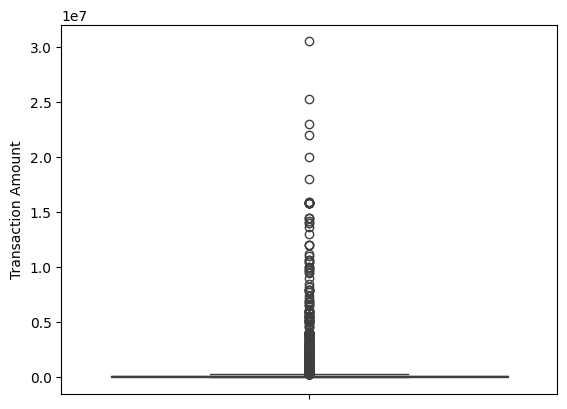

In [62]:
sns.boxplot(df['Transaction Amount'])

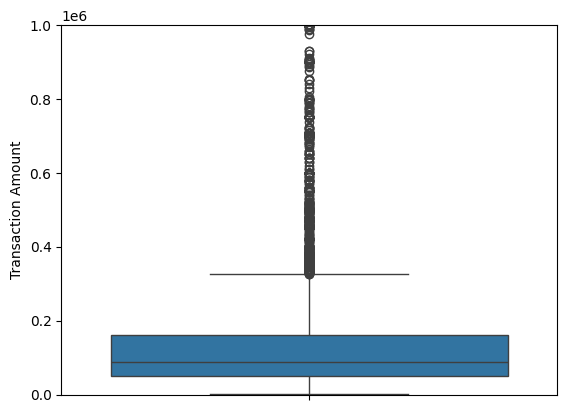

In [63]:
sns.boxplot(df['Transaction Amount'])
plt.ylim(0, 0.1e7)  
plt.show()

## Menemukan Korelasi Data

In [67]:
df['Paid Date']=pd.to_datetime(df['Paid Date'], format='%Y%m%d')

In [68]:
numeric_df=df.select_dtypes(include=[np.number])
numeric_df

,Order Number,Transaction Amount,Seller Discount,Sales Discount,Delivery Fee,Other Discount
0,201707240088517,300000,153000,10200.0,9000,0.0
1,201707018889790,287800,68000,0.0,0,0.0
2,201707079264675,35000,0,700.0,0,0.0
3,201707209945714,85000,0,5900.0,0,0.0
4,201707220002354,81000,0,5600.0,0,0.0
...,...,...,...,...,...,...
11995,201712012704898,333000,300000,2300.0,0,0.0
11996,201712032723513,280000,222500,0.0,0,0.0
11997,201712042740205,150000,81000,4800.0,0,0.0
11998,201712072778621,475000,400000,0.0,0,0.0


In [69]:
correlation_matrix = numeric_df.corr()

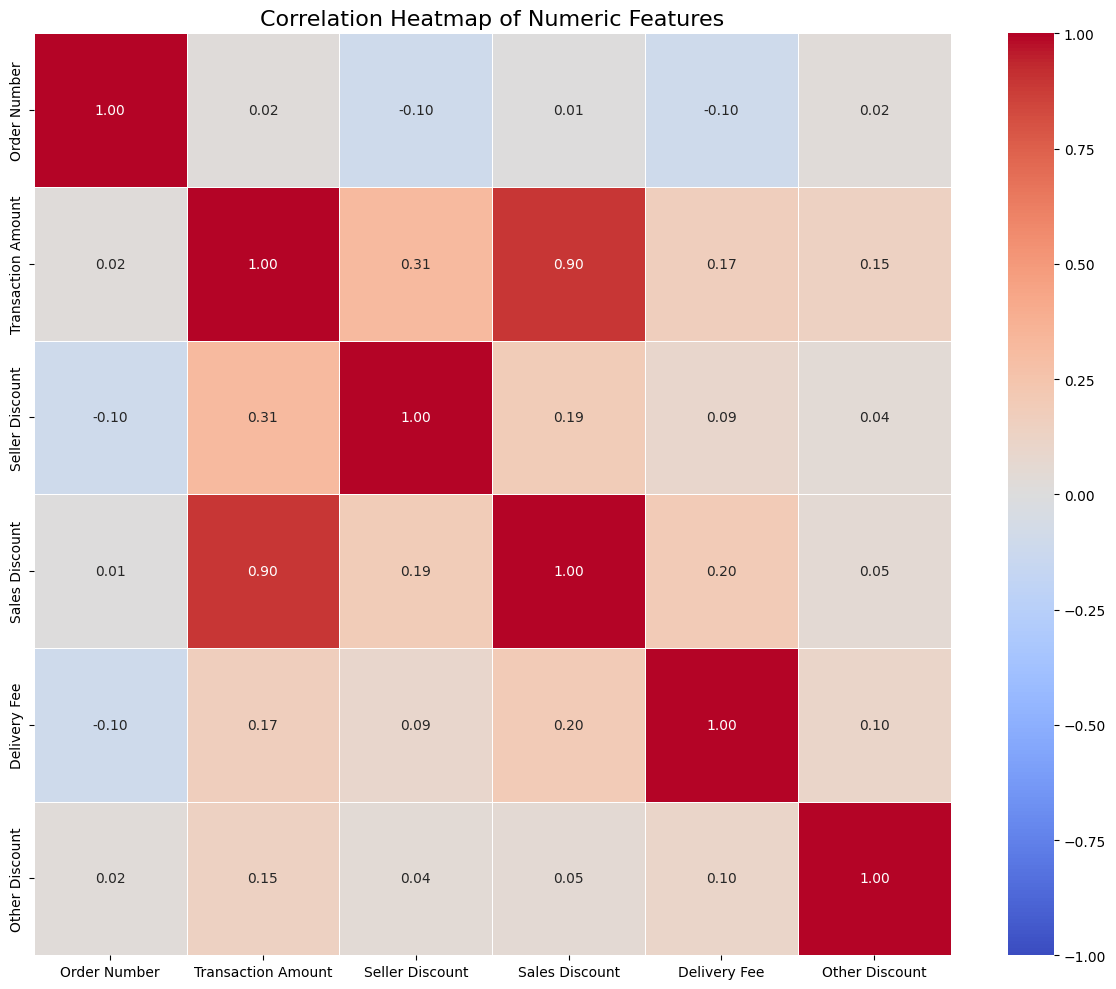

In [71]:
plt.figure(figsize=(12, 10))

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, vmin=-1, vmax=1)               

plt.title('Correlation Heatmap of Numeric Features', fontsize=16)
plt.tight_layout()
plt.show()

## Visualisasi Data

In [72]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Paid Date           12000 non-null  datetime64[ns]
 1   Order Number        12000 non-null  int64         
 2   First Name          11996 non-null  object        
 3   Last Name           11996 non-null  object        
 4   Meta Category       12000 non-null  object        
 5   Product Name        12000 non-null  object        
 6   Transaction Amount  12000 non-null  int64         
 7   Seller Discount     12000 non-null  int64         
 8   Sales Discount      12000 non-null  float64       
 9   Delivery Fee        12000 non-null  int64         
 10  Other Discount      12000 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(4), object(4)
memory usage: 1.0+ MB


In [83]:
df["Paid Date"] = pd.to_datetime(df["Paid Date"])

In [75]:
df['Bulan'] = df['Paid Date'].dt.to_period('M')

In [80]:
penjualan=df.groupby('Bulan')['Transaction Amount'].sum().reset_index()

In [81]:
penjualan

,Bulan,Transaction Amount
0,2017-07,508364300
1,2017-08,545720000
2,2017-09,553212800
3,2017-10,295796600
4,2017-11,662328900
5,2017-12,640144300


In [84]:
penjualan["Bulan"] = penjualan["Bulan"].dt.to_timestamp()

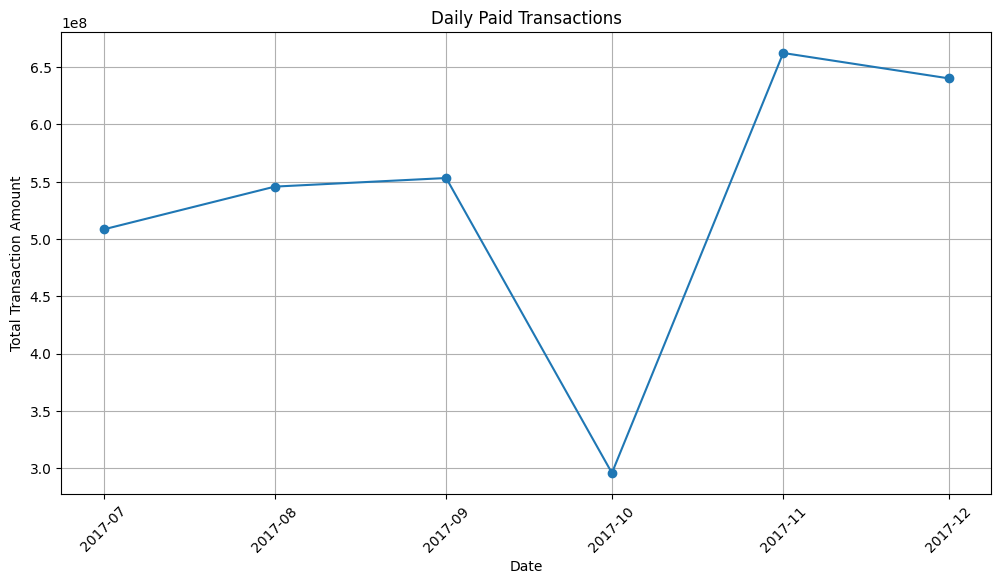

In [85]:
plt.figure(figsize=(12, 6))
plt.plot(penjualan["Bulan"], penjualan["Transaction Amount"], marker='o', linestyle='-')
plt.xlabel("Date")
plt.ylabel("Total Transaction Amount")
plt.title("Daily Paid Transactions")
plt.xticks(rotation=45)
plt.grid()
plt.show()

In [86]:
meta_sales = df.groupby("Meta Category")["Transaction Amount"].sum().reset_index()
meta_sales = meta_sales.sort_values(by="Transaction Amount", ascending=False)

In [87]:
meta_sales

,Meta Category,Transaction Amount
6,Service/ Mokado,1553091800
3,Fashion,497267800
5,Home/ Food,370359100
4,Gadget/ Komputer,290581200
1,Beauty/ Health,260650800
0,Babies/ Kids,131241200
7,Sports/ Hobi/ Otomotif,71047100
2,Elektronik,31327900


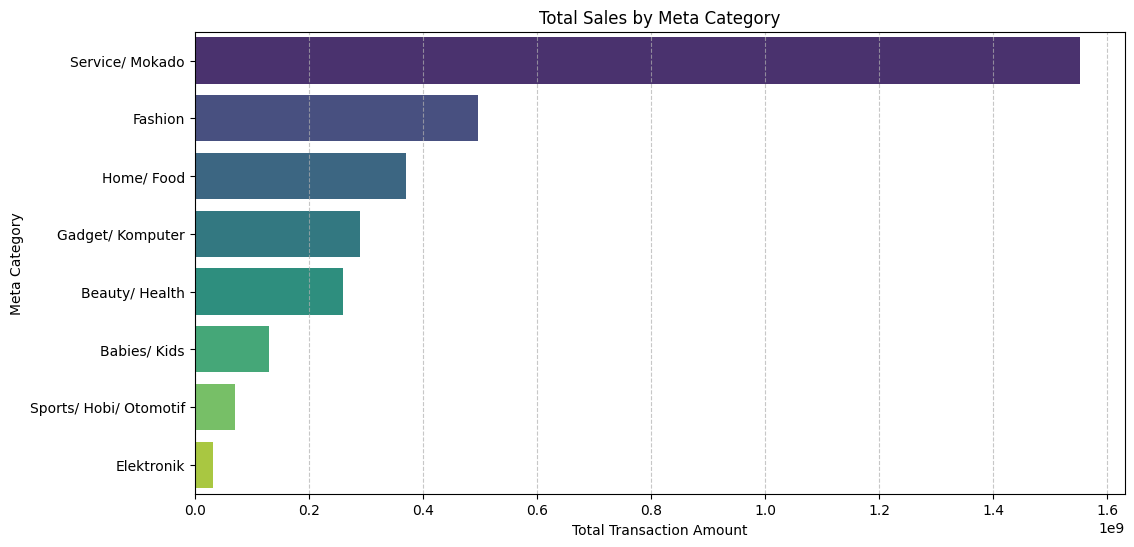

In [88]:
plt.figure(figsize=(12, 6))
sns.barplot(data=meta_sales, x="Transaction Amount", y="Meta Category", palette="viridis")

plt.xlabel("Total Transaction Amount")
plt.ylabel("Meta Category")
plt.title("Total Sales by Meta Category")
plt.grid(axis="x", linestyle="--", alpha=0.7)

plt.show()